# SolarShield — Exploratory Data Analysis
## Community-Level Solar Inverter Cyber Risk

This notebook walks through the primary modeling dataset: `community_model_inputs_census_nationwide.csv`.

**What this dataset is:**  
32,958 ZIP Code Tabulation Areas (ZCTAs) across the United States, each scored on their likelihood of containing vulnerable residential solar inverter infrastructure. Features are derived from two sources:

1. **U.S. Census ACS 5-year estimates (2022)** — community-level housing, ownership, and demographic data
2. **NVD/CISA CVE intelligence** — curated cyber threat priors from known solar inverter vulnerabilities

**The modeling question:**  
Which U.S. communities are most likely to contain vulnerable, internet-exposed solar inverters — before a single device is scanned?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

REPO_ROOT = Path('..').resolve()
PROCESSED = REPO_ROOT / 'data' / 'processed'
OUTPUT = REPO_ROOT / 'output'

---
## 1. Load the Modeling Dataset

In [24]:
df = pd.read_csv(PROCESSED / 'community_model_inputs_census_nationwide.csv', dtype={'geo_id': str})
df['geo_id'] = df['geo_id'].str.zfill(5)  # Ensure 5-digit ZIP format

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape: 32,958 rows × 34 columns
Memory: 12.2 MB


---
## 2. Schema — Column Overview

The dataset has 34 columns across four logical groups:

In [40]:
schema = {
    'geo_id':                        ('ID',        'ZCTA 5-digit code (ZIP approximation)'),
    'NAME':                          ('ID',        'ZCTA label from Census API'),
    'total_housing_units':           ('Housing',   'Total housing units in ZCTA'),
    'occupied_units':                ('Housing',   'Occupied (non-vacant) units'),
    'owner_occupied_units':          ('Housing',   'Owner-occupied units'),
    'renter_occupied_units':         ('Housing',   'Renter-occupied units'),
    'single_family_detached_units':  ('Housing',   'Detached single-family homes'),
    'single_family_attached_units':  ('Housing',   'Attached single-family (townhouses etc.)'),
    'parcel_count':                  ('Housing',   'Alias for total_housing_units'),
    'residential_parcel_count':      ('Housing',   'Alias for occupied_units'),
    'single_family_count':           ('Housing',   'Alias for single_family_detached_units'),
    'solar_candidate_count':         ('Housing',   'Estimated owner-occupied SF units (prime solar targets)'),
    'housing_density_proxy':         ('Housing',   'Unit count used as density proxy (no area data)'),
    'single_family_share':           ('Feature',   'SF detached / total units — key solar predictor'),
    'residential_share':             ('Feature',   'Occupied / total units'),
    'owner_occupancy_rate':          ('Feature',   'Owner-occupied / occupied units — solar install proxy'),
    'solar_candidate_share':         ('Feature',   'Owner-occupied SF homes / total units — primary target'),
    'high_value_share':              ('Feature',   '1 if median home value ≥ $1M, else 0'),
    'median_home_value':             ('Feature',   'Census median home value ($)'),
    'median_final_value':            ('Feature',   'Same as median_home_value (alias)'),
    'median_household_income':       ('Feature',   'Census median household income ($)'),
    'median_year_built':             ('Feature',   'Median construction year of housing stock'),
    'median_property_age':           ('Feature',   '2026 − median_year_built'),
    'total_population':              ('Demo',      'Total population in ZCTA'),
    'solar_cve_count':               ('Cyber',     'Unique CVEs affecting solar vendors (global constant)'),
    'solar_critical_cve_count':      ('Cyber',     'CVEs with CVSS ≥ 9.0 (global constant)'),
    'solar_kev_cve_count':           ('Cyber',     'CVEs in CISA KEV catalog (global constant)'),
    'solar_vendor_count':            ('Cyber',     'Number of affected solar vendors (global constant)'),
    'solar_avg_cvss':                ('Cyber',     'Mean CVSS across solar CVEs (global constant)'),
    'solar_max_cvss':                ('Cyber',     'Max CVSS across solar CVEs (global constant)'),
    'solar_avg_vendor_risk':         ('Cyber',     'Mean vendor risk score (global constant)'),
    'solar_cyber_pressure_score':    ('Cyber',     'Composite cyber threat index 0–100 (global constant)'),
    'solar_readiness_score':         ('Score',     'Community solar adoption likelihood 0–100'),
    'community_risk_prior_score':    ('Score',     'Final composite risk score 0–100 (PRIMARY TARGET)'),
}

schema_df = pd.DataFrame(
    [(col, grp, desc) for col, (grp, desc) in schema.items()],
    columns=['Column', 'Group', 'Description']
)
schema_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,Column,Group,Description
0,geo_id,ID,ZCTA 5-digit code (ZIP approximation)
1,NAME,ID,ZCTA label from Census API
2,total_housing_units,Housing,Total housing units in ZCTA
3,occupied_units,Housing,Occupied (non-vacant) units
4,owner_occupied_units,Housing,Owner-occupied units
5,renter_occupied_units,Housing,Renter-occupied units
6,single_family_detached_units,Housing,Detached single-family homes
7,single_family_attached_units,Housing,Attached single-family (townhouses etc.)
8,parcel_count,Housing,Alias for total_housing_units
9,residential_parcel_count,Housing,Alias for occupied_units


In [41]:
# First 5 rows
df.head()

,geo_id,NAME,parcel_count,residential_parcel_count,single_family_count,solar_candidate_count,single_family_share,residential_share,owner_occupancy_rate,solar_candidate_share,high_value_share,median_final_value,median_home_value,median_household_income,median_year_built,median_property_age,total_population,total_housing_units,occupied_units,owner_occupied_units,renter_occupied_units,single_family_detached_units,single_family_attached_units,housing_density_proxy,solar_cve_count,solar_critical_cve_count,solar_kev_cve_count,solar_vendor_count,solar_avg_cvss,solar_max_cvss,solar_avg_vendor_risk,solar_cyber_pressure_score,solar_readiness_score,community_risk_prior_score
0,94548,ZCTA5 94548,211,211,211,211,1.0000,1.0000,1.0000,1.0000,1.0000,1041700.0000,1041700.0000,166597.0000,1993.0000,33.0000,598,211,211,211,0,211,0,211,83,33,1,13,8.1518,10.0000,44.2915,61.4800,90.0000,77.1700
1,21153,ZCTA5 21153,268,268,268,259,1.0000,1.0000,0.9664,0.9664,1.0000,1045800.0000,1045800.0000,NaN,1982.0000,44.0000,676,268,268,259,9,268,0,268,83,33,1,13,8.1518,10.0000,44.2915,61.4800,89.3284,76.8000
2,18933,ZCTA5 18933,75,75,75,69,1.0000,1.0000,0.9200,0.9200,1.0000,1110300.0000,1110300.0000,211328.0000,1938.0000,88.0000,126,75,75,69,6,75,0,75,83,33,1,13,8.1518,10.0000,44.2915,61.4800,88.4000,76.2900
3,40025,ZCTA5 40025,229,220,229,217,1.0000,0.9607,0.9455,0.9455,1.0000,1122200.0000,1122200.0000,250001.0000,1972.0000,54.0000,560,229,220,208,12,229,0,229,83,33,1,13,8.1518,10.0000,44.2915,61.4800,87.9266,76.0300
4,22066,ZCTA5 22066,5806,5671,5720,5416,0.9852,0.9767,0.9469,0.9329,1.0000,1199400.0000,1199400.0000,250001.0000,1984.0000,42.0000,16925,5806,5671,5370,301,5720,67,5806,83,33,1,13,8.1518,10.0000,44.2915,61.4800,87.5582,75.8200


---
## 3. Descriptive Statistics

Focus on the feature and score columns — the raw counts (parcel_count, total_housing_units etc.) are structural duplicates.

In [42]:
feature_cols = [
    'single_family_share', 'residential_share', 'owner_occupancy_rate',
    'solar_candidate_share', 'high_value_share',
    'median_home_value', 'median_household_income',
    'median_year_built', 'median_property_age',
    'total_population', 'total_housing_units',
    'solar_readiness_score', 'community_risk_prior_score'
]

df[feature_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
single_family_share,32958.0000,0.7300,0.2000,0.0000,0.6400,0.7600,0.8700,1.0000
residential_share,32958.0000,0.8300,0.1700,0.0000,0.7700,0.8800,0.9400,1.0000
owner_occupancy_rate,32958.0000,0.7400,0.1900,0.0000,0.6700,0.7800,0.8700,1.0000
solar_candidate_share,32958.0000,0.5600,0.2300,0.0000,0.4300,0.5800,0.7200,1.0000
high_value_share,32958.0000,0.0200,0.1300,0.0000,0.0000,0.0000,0.0000,1.0000
median_home_value,30379.0000,258945.0800,229367.4800,9999.0000,124300.0000,189500.0000,304400.0000,2000001.0000
median_household_income,30621.0000,73132.6300,31359.5800,2499.0000,53466.0000,66993.0000,85313.0000,250001.0000
median_year_built,32268.0000,1974.2200,16.4200,1938.0000,1964.0000,1976.0000,1986.0000,2021.0000
median_property_age,32268.0000,51.7800,16.4200,5.0000,40.0000,50.0000,62.0000,88.0000
total_population,32958.0000,10129.9100,15017.2000,0.0000,705.0000,2817.0000,13899.2500,134008.0000


### Key observations from descriptive stats:

- **`solar_candidate_share`** (owner-occupied single-family rate): mean **0.56**, ranging 0–1. This is the single strongest feature for identifying high-adoption zones.
- **`median_home_value`**: highly right-skewed (mean $259K vs median $190K). Wealthy communities that can afford solar are in the long tail.
- **`community_risk_prior_score`**: ranges **27.7 – 77.2**, mean **59.2**, std **6.5**. Relatively tight distribution — variation is driven almost entirely by `solar_readiness_score` since the cyber pressure component is a global constant.
- **`median_household_income`**: 7% missing (rural ZCTAs with too few households to report).

---
## 4. Missing Data Audit

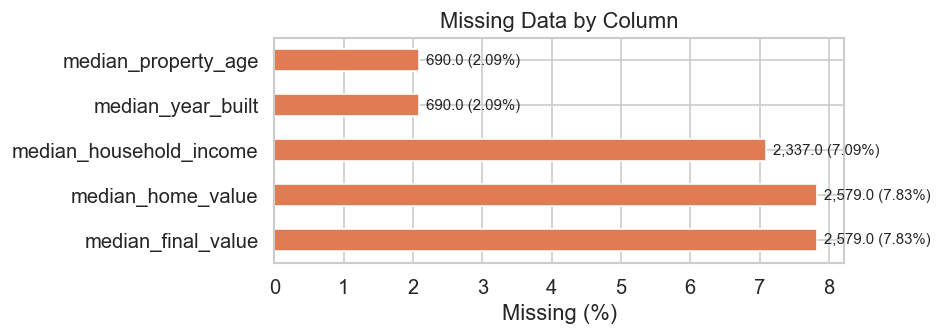


Note: median_home_value and median_final_value are identical — one is an alias.
Missing values are concentrated in rural/sparse ZCTAs where Census suppresses small-sample estimates.


In [43]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 3))
missing_df['missing_pct'].plot(kind='barh', ax=ax, color='#e07b54')
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Data by Column')
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row['missing_pct'] + 0.1, i, f"{row['missing_count']:,} ({row['missing_pct']}%)", va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nNote: median_home_value and median_final_value are identical — one is an alias.')
print('Missing values are concentrated in rural/sparse ZCTAs where Census suppresses small-sample estimates.')

---
## 5. Score Distribution — The Primary Target

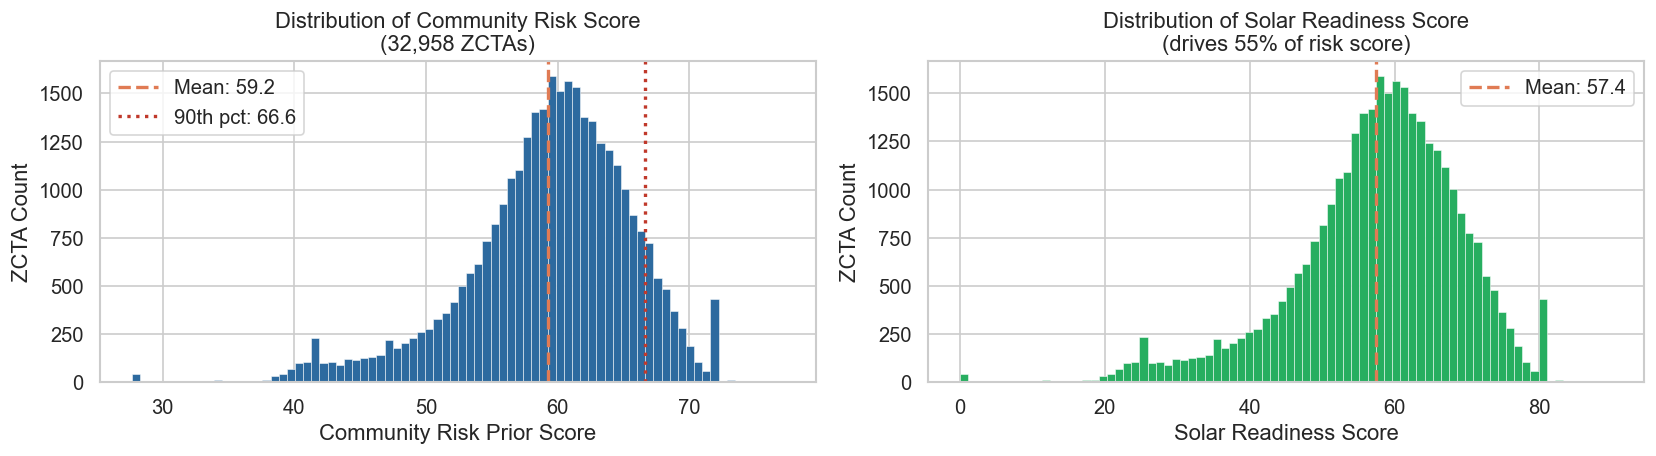

Top 10% risk threshold: 66.6
ZCTAs in top 10%: 3,306


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Community risk score
ax = axes[0]
ax.hist(df['community_risk_prior_score'], bins=80, color='#2d6a9f', edgecolor='white', linewidth=0.3)
ax.axvline(df['community_risk_prior_score'].mean(), color='#e07b54', linestyle='--', linewidth=2, label=f"Mean: {df['community_risk_prior_score'].mean():.1f}")
ax.axvline(df['community_risk_prior_score'].quantile(0.9), color='#c0392b', linestyle=':', linewidth=2, label=f"90th pct: {df['community_risk_prior_score'].quantile(0.9):.1f}")
ax.set_xlabel('Community Risk Prior Score')
ax.set_ylabel('ZCTA Count')
ax.set_title('Distribution of Community Risk Score\n(32,958 ZCTAs)')
ax.legend()

# Solar readiness
ax = axes[1]
ax.hist(df['solar_readiness_score'], bins=80, color='#27ae60', edgecolor='white', linewidth=0.3)
ax.axvline(df['solar_readiness_score'].mean(), color='#e07b54', linestyle='--', linewidth=2, label=f"Mean: {df['solar_readiness_score'].mean():.1f}")
ax.set_xlabel('Solar Readiness Score')
ax.set_ylabel('ZCTA Count')
ax.set_title('Distribution of Solar Readiness Score\n(drives 55% of risk score)')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Top 10% risk threshold: {df['community_risk_prior_score'].quantile(0.9):.1f}")
print(f"ZCTAs in top 10%: {(df['community_risk_prior_score'] >= df['community_risk_prior_score'].quantile(0.9)).sum():,}")

---
## 6. Key Feature Distributions

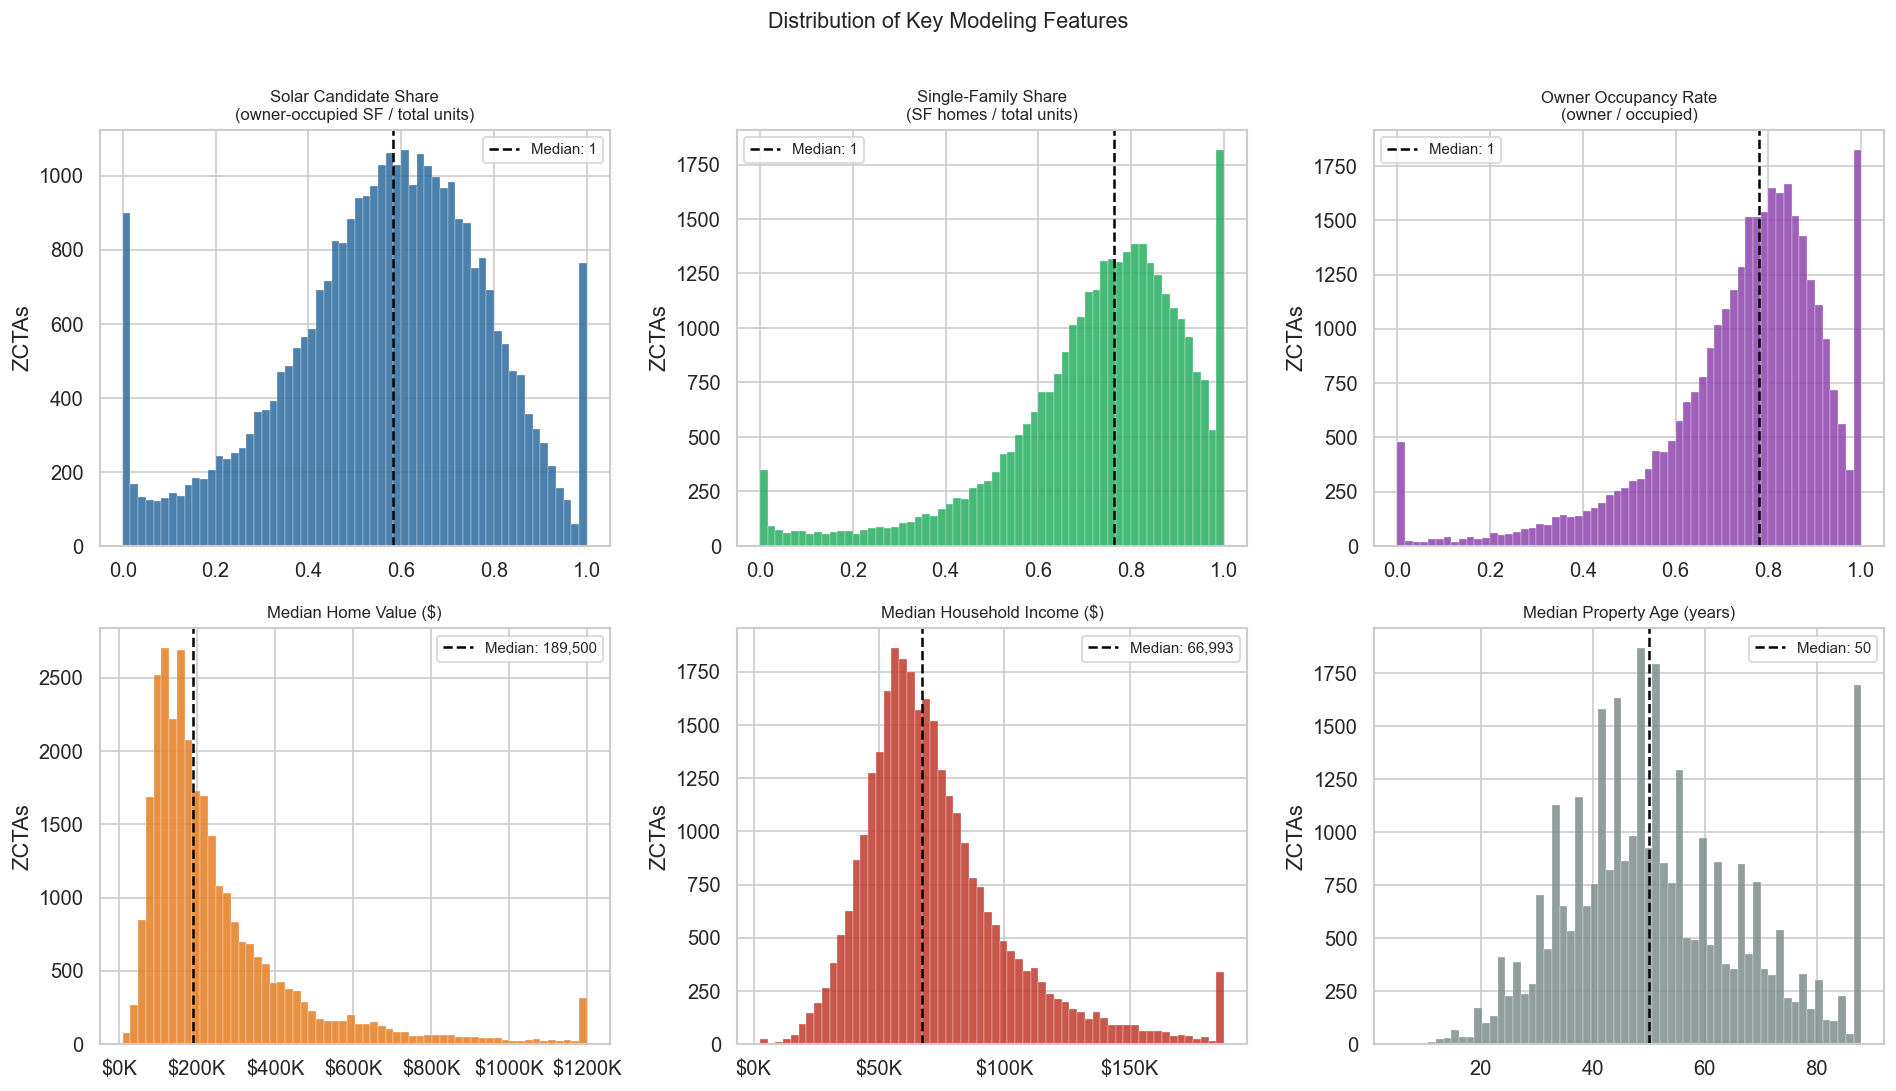

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plots = [
    ('solar_candidate_share',   'Solar Candidate Share\n(owner-occupied SF / total units)',      '#2d6a9f'),
    ('single_family_share',     'Single-Family Share\n(SF homes / total units)',                '#27ae60'),
    ('owner_occupancy_rate',    'Owner Occupancy Rate\n(owner / occupied)',                     '#8e44ad'),
    ('median_home_value',       'Median Home Value ($)',                                        '#e67e22'),
    ('median_household_income', 'Median Household Income ($)',                                  '#c0392b'),
    ('median_property_age',     'Median Property Age (years)',                                  '#7f8c8d'),
]

for ax, (col, title, color) in zip(axes.flat, plots):
    data = df[col].dropna()
    # Clip extreme values for readability
    p99 = data.quantile(0.99)
    data_clipped = data.clip(upper=p99)
    ax.hist(data_clipped, bins=60, color=color, edgecolor='white', linewidth=0.2, alpha=0.85)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {data.median():,.0f}')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('ZCTAs')
    ax.legend(fontsize=9)
    if col in ('median_home_value', 'median_household_income'):
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Distribution of Key Modeling Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Feature structure observations:

- **`solar_candidate_share`**: roughly normal centered around 0.55. ZCTAs with very low values are urban high-density areas (apartments dominate). Values near 1.0 are rural/suburban communities that are almost entirely owner-occupied single-family.
- **`single_family_share`** and **`owner_occupancy_rate`**: both skewed toward higher values — most U.S. ZCTAs are predominantly residential and owner-occupied. The key discriminator is the *combination* of both.
- **`median_home_value`**: strongly right-skewed. Clipped at 99th percentile ($1.06M) for readability. Luxury ZCTAs in CA and NY extend to $2M+.
- **`median_household_income`**: Census caps reporting at $250,001 — the spike at the right is a data artifact, not real variation.
- **`median_property_age`**: bimodal — a cluster of newer communities (20–30 years, post-1990s sunbelt development) and older housing stock (50–70 years, Northeast/Midwest).

---
## 7. Top and Bottom Risk ZCTAs

In [46]:
display_cols = [
    'geo_id', 'NAME', 'community_risk_prior_score', 'solar_readiness_score',
    'solar_candidate_share', 'single_family_share', 'owner_occupancy_rate',
    'median_home_value', 'median_household_income', 'total_housing_units'
]

print('=== TOP 15 HIGHEST RISK ZCTAs ===')
df[display_cols].head(15).style.background_gradient(subset=['community_risk_prior_score'], cmap='Reds')

=== TOP 15 HIGHEST RISK ZCTAs ===


,geo_id,NAME,community_risk_prior_score,solar_readiness_score,solar_candidate_share,single_family_share,owner_occupancy_rate,median_home_value,median_household_income,total_housing_units
0,94548,ZCTA5 94548,77.170000,90.000000,1.000000,1.000000,1.000000,1041700.000000,166597.000000,211
1,21153,ZCTA5 21153,76.800000,89.328358,0.966418,1.000000,0.966418,1045800.000000,nan,268
2,18933,ZCTA5 18933,76.290000,88.400000,0.920000,1.000000,0.920000,1110300.000000,211328.000000,75
3,40025,ZCTA5 40025,76.030000,87.926558,0.945455,1.000000,0.945455,1122200.000000,250001.000000,229
4,22066,ZCTA5 22066,75.820000,87.558213,0.932897,0.985188,0.946923,1199400.000000,250001.000000,5806
5,02468,ZCTA5 02468,75.600000,87.157000,0.930182,0.964087,0.964832,1659100.000000,250001.000000,1977
6,83414,ZCTA5 83414,75.420000,86.830189,0.841509,1.000000,0.841509,1121400.000000,160938.000000,265
7,94528,ZCTA5 94528,75.220000,86.455224,1.000000,1.000000,1.000000,2000001.000000,250001.000000,268
8,10506,ZCTA5 10506,75.210000,86.446557,0.948443,0.991932,0.956157,1041600.000000,236071.000000,2355
9,60043,ZCTA5 60043,75.080000,86.201296,0.929486,0.966224,0.961977,1358000.000000,250001.000000,829


In [47]:
print('=== BOTTOM 10 LOWEST RISK ZCTAs (high density / renter-dominated) ===')
df[display_cols].tail(10).style.background_gradient(subset=['community_risk_prior_score'], cmap='Blues_r')

=== BOTTOM 10 LOWEST RISK ZCTAs (high density / renter-dominated) ===


,geo_id,NAME,community_risk_prior_score,solar_readiness_score,solar_candidate_share,single_family_share,owner_occupancy_rate,median_home_value,median_household_income,total_housing_units
32948,07703,ZCTA5 07703,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,76
32949,88349,ZCTA5 88349,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,51
32950,76908,ZCTA5 76908,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,6
32951,45739,ZCTA5 45739,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,13
32952,79699,ZCTA5 79699,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,49
32953,10152,ZCTA5 10152,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,104
32954,93928,ZCTA5 93928,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,9
32955,72053,ZCTA5 72053,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,25
32956,40526,ZCTA5 40526,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,10
32957,24850,ZCTA5 24850,27.670000,0.000000,0.000000,0.000000,0.000000,nan,nan,8


---
## 8. Score Decomposition — What's Driving Risk?

The risk score formula:  
`community_risk_prior_score = 0.55 × solar_readiness_score + 0.45 × solar_cyber_pressure_score`

**Important caveat:** `solar_cyber_pressure_score` is currently a **global constant** (61.48 for all ZCTAs — same CVE landscape applies everywhere). Variation in the risk score is therefore entirely driven by `solar_readiness_score`.

This is a v1 design choice — the cyber pressure component is a prior that weights all communities equally by the global CVE threat. A future version could vary by vendor market share per region.

In [48]:
# Verify: cyber pressure is a constant
print(f"solar_cyber_pressure_score unique values: {df['solar_cyber_pressure_score'].nunique()}")
print(f"Value: {df['solar_cyber_pressure_score'].iloc[0]}")
print()
print('Score formula breakdown for top ZCTA:')
top = df.iloc[0]
print(f"  solar_readiness_score:       {top['solar_readiness_score']:.2f}")
print(f"  solar_cyber_pressure_score:  {top['solar_cyber_pressure_score']:.2f}")
print(f"  0.55 × {top['solar_readiness_score']:.2f} + 0.45 × {top['solar_cyber_pressure_score']:.2f} = {top['community_risk_prior_score']:.2f}")

solar_cyber_pressure_score unique values: 1
Value: 61.48

Score formula breakdown for top ZCTA:
  solar_readiness_score:       90.00
  solar_cyber_pressure_score:  61.48
  0.55 × 90.00 + 0.45 × 61.48 = 77.17


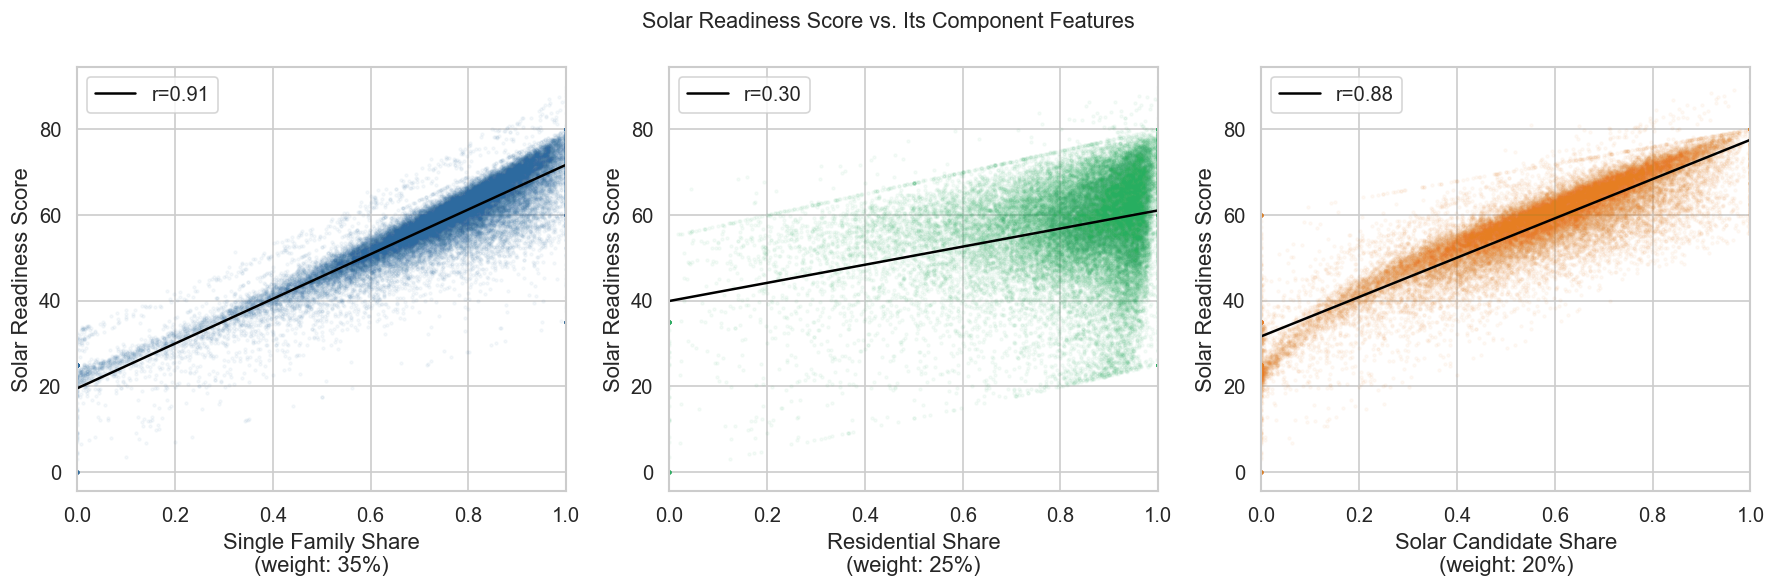

In [34]:
# Solar readiness decomposition
# readiness = (0.35*sf_share + 0.25*res_share + 0.20*solar_cand + 0.10*hv_share + 0.10*garage) * 100
# No garage data from Census — effectively: readiness driven by sf_share, res_share, solar_candidate_share

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

components = [
    ('single_family_share',   'Single Family Share\n(weight: 35%)',       '#2d6a9f'),
    ('residential_share',     'Residential Share\n(weight: 25%)',         '#27ae60'),
    ('solar_candidate_share', 'Solar Candidate Share\n(weight: 20%)',     '#e67e22'),
]

for ax, (col, label, color) in zip(axes, components):
    ax.scatter(
        df[col], df['solar_readiness_score'],
        alpha=0.04, s=3, color=color
    )
    # Trend line
    m, b = np.polyfit(df[col].fillna(0), df['solar_readiness_score'], 1)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, label=f'r={df[col].corr(df["solar_readiness_score"]):.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Solar Readiness Score')
    ax.legend()
    ax.set_xlim(0, 1)

plt.suptitle('Solar Readiness Score vs. Its Component Features', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Correlation Matrix — Feature Relationships

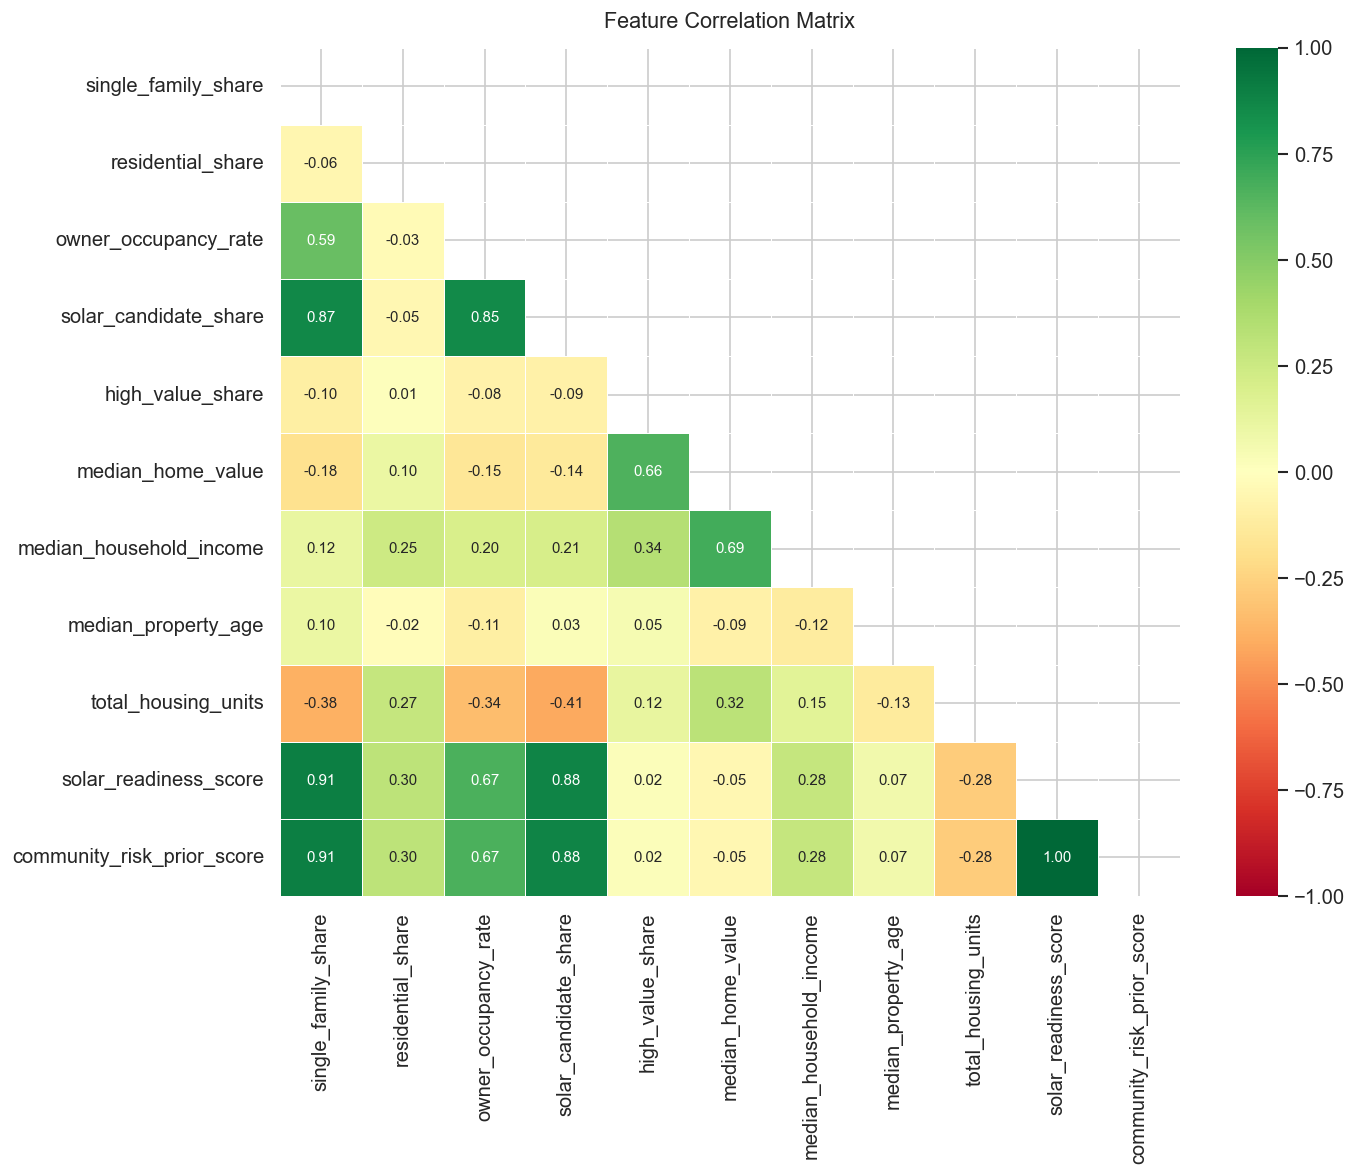

In [35]:
corr_cols = [
    'single_family_share', 'residential_share', 'owner_occupancy_rate',
    'solar_candidate_share', 'high_value_share',
    'median_home_value', 'median_household_income',
    'median_property_age', 'total_housing_units',
    'solar_readiness_score', 'community_risk_prior_score'
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

In [36]:
# Correlation with the target score
target_corr = df[corr_cols].corr()['community_risk_prior_score'].drop('community_risk_prior_score').sort_values(ascending=False)
print('Correlation with community_risk_prior_score:')
print(target_corr.to_string())

Correlation with community_risk_prior_score:
solar_readiness_score      1.0000
single_family_share        0.9056
solar_candidate_share      0.8825
owner_occupancy_rate       0.6653
residential_share          0.3047
median_household_income    0.2754
median_property_age        0.0742
high_value_share           0.0182
median_home_value         -0.0508
total_housing_units       -0.2803


### Correlation findings:

- **`single_family_share`** is the strongest individual predictor of risk — makes sense as the primary solar installation proxy
- **`owner_occupancy_rate`** and **`residential_share`** are highly correlated with each other and with `single_family_share` — this multi-collinearity is expected and handled by the scoring formula's explicit weighting
- **`median_home_value`** shows moderate positive correlation — higher-value homes have more solar (consistent with adoption data)
- **`total_housing_units`** is mildly *negatively* correlated — large ZCTAs tend to be urban/dense with lower SF rates
- **`median_property_age`** is slightly negative — older housing stock has less rooftop solar (pre-dates net metering era)

---
## 10. Cyber Threat Intelligence — The Vendor Risk Landscape

In [37]:
vendors = pd.read_csv(OUTPUT / 'vendor_risk_priors.csv')
print(f'{len(vendors)} solar vendors with CVE data')
vendors.sort_values('vendor_risk_score', ascending=False)

13 solar vendors with CVE data


,vendor,cve_count,product_count,critical_cve_count,high_or_worse_count,kev_cve_count,avg_cvss,max_cvss,avg_vuln_weight,vendor_risk_score
1,Sungrow,15,2,9,12,0,8.2188,9.8000,0.9625,65.7400
2,Growatt,5,1,3,3,0,8.0400,9.8000,0.9540,65.3800
0,SMA,17,42,8,15,0,8.6521,10.0000,1.0097,64.0700
3,Fronius,2,66,1,1,0,8.1500,9.8000,0.9400,63.1000
5,Contec,25,3,8,18,1,7.9313,9.8000,0.8791,58.9600
6,Enphase,14,4,4,10,0,7.9000,9.8000,0.8594,57.2400
4,Tesla,1,1,0,1,0,8.8000,8.8000,0.8800,48.4000
7,SolarEdge,1,1,0,0,0,5.4000,5.4000,0.5400,29.7000
8,Sloan,1,71,0,0,0,5.4000,5.4000,0.5400,29.7000
9,Solis,1,1,0,0,0,5.3000,5.3000,0.5300,29.1500


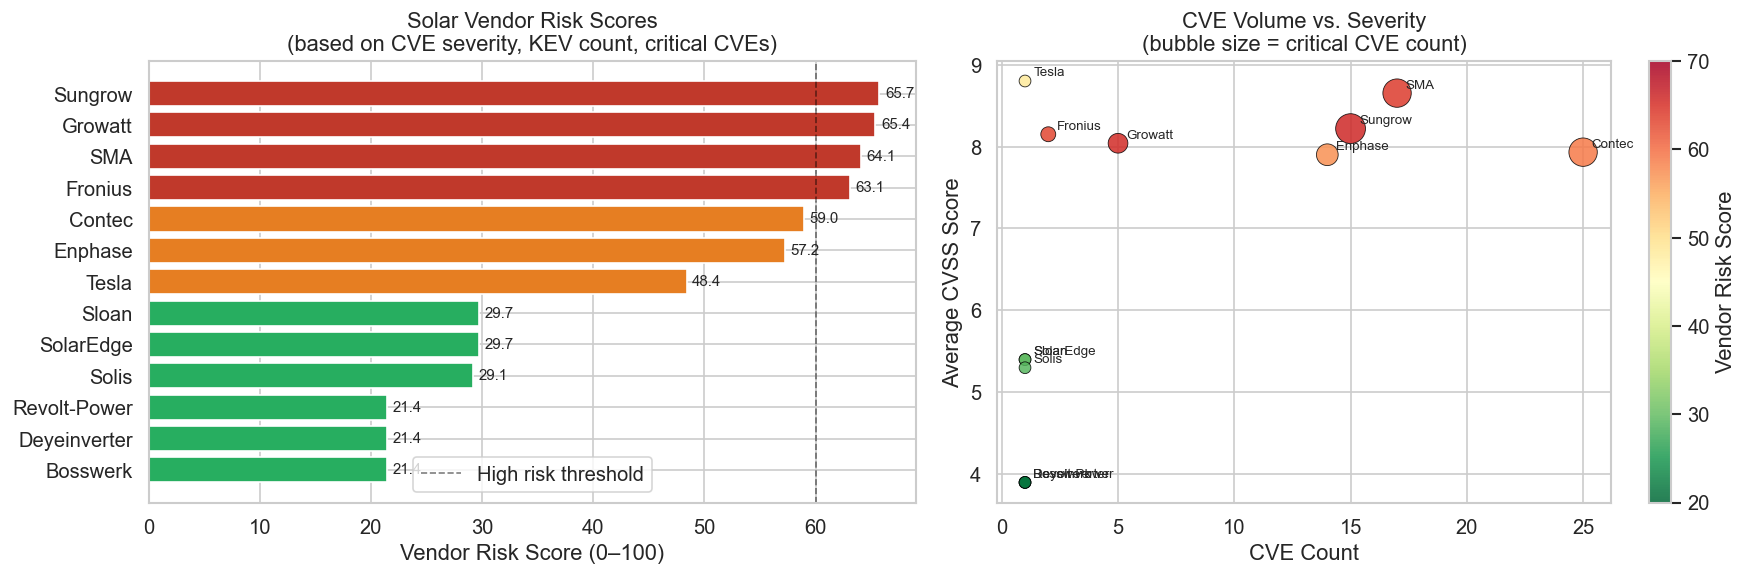

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Vendor risk scores
ax = axes[0]
vendors_sorted = vendors.sort_values('vendor_risk_score', ascending=True)
colors = ['#c0392b' if s >= 60 else '#e67e22' if s >= 40 else '#27ae60' for s in vendors_sorted['vendor_risk_score']]
bars = ax.barh(vendors_sorted['vendor'], vendors_sorted['vendor_risk_score'], color=colors)
ax.set_xlabel('Vendor Risk Score (0–100)')
ax.set_title('Solar Vendor Risk Scores\n(based on CVE severity, KEV count, critical CVEs)')
ax.axvline(60, color='black', linestyle='--', linewidth=1, alpha=0.5, label='High risk threshold')
for bar, val in zip(bars, vendors_sorted['vendor_risk_score']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
ax.legend()

# CVE count vs avg CVSS
ax = axes[1]
scatter = ax.scatter(
    vendors['cve_count'], vendors['avg_cvss'],
    s=vendors['critical_cve_count'] * 30 + 50,
    c=vendors['vendor_risk_score'], cmap='RdYlGn_r',
    vmin=20, vmax=70, edgecolors='black', linewidths=0.5, alpha=0.85
)
for _, row in vendors.iterrows():
    ax.annotate(row['vendor'], (row['cve_count'], row['avg_cvss']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)
plt.colorbar(scatter, ax=ax, label='Vendor Risk Score')
ax.set_xlabel('CVE Count')
ax.set_ylabel('Average CVSS Score')
ax.set_title('CVE Volume vs. Severity\n(bubble size = critical CVE count)')

plt.tight_layout()
plt.show()

---
## 11. CVE Intelligence Deep Dive

In [39]:
cves = pd.read_csv(OUTPUT / 'high_confidence_solar_affected_products.csv')
cves['cvss_score'] = pd.to_numeric(cves['cvss_score'], errors='coerce')
cves['published_date'] = pd.to_datetime(cves['published_date'], errors='coerce')

print(f'Curated solar CVEs: {cves["cve_id"].nunique()} unique CVEs across {cves["vendor"].nunique()} vendors')
print(f'Date range: {cves["published_date"].min().date()} – {cves["published_date"].max().date()}')
print(f'Critical CVEs (CVSS ≥ 9.0): {(cves["cvss_score"] >= 9.0).sum()}')
print(f'Max CVSS: {cves["cvss_score"].max()}')

Curated solar CVEs: 83 unique CVEs across 13 vendors
Date range: 2015-09-11 – 2025-12-13
Critical CVEs (CVSS ≥ 9.0): 366
Max CVSS: 10.0


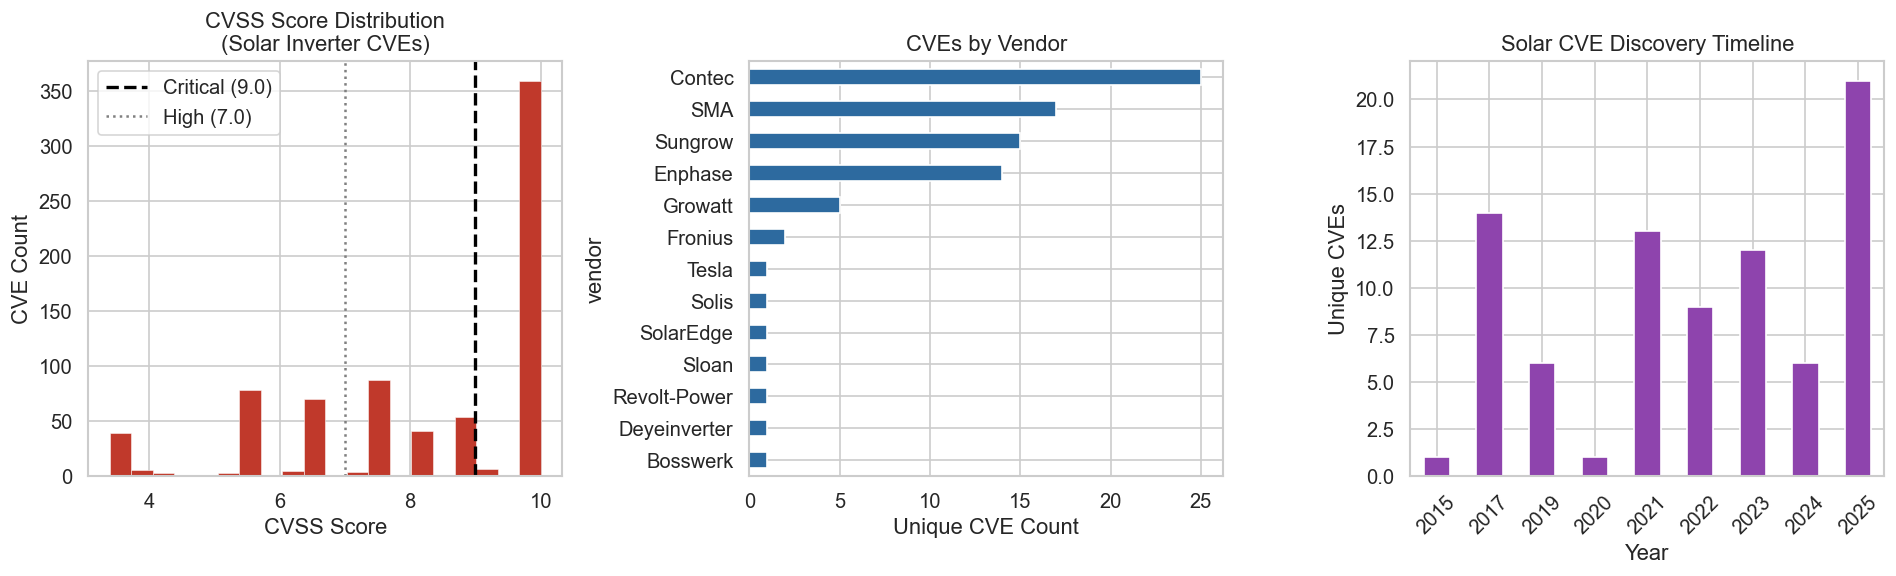

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# CVSS distribution
ax = axes[0]
ax.hist(cves['cvss_score'].dropna(), bins=20, color='#c0392b', edgecolor='white', linewidth=0.3)
ax.axvline(9.0, color='black', linestyle='--', linewidth=2, label='Critical (9.0)')
ax.axvline(7.0, color='grey', linestyle=':', linewidth=1.5, label='High (7.0)')
ax.set_xlabel('CVSS Score')
ax.set_ylabel('CVE Count')
ax.set_title('CVSS Score Distribution\n(Solar Inverter CVEs)')
ax.legend()

# CVEs per vendor
ax = axes[1]
cve_by_vendor = cves.groupby('vendor')['cve_id'].nunique().sort_values(ascending=True)
cve_by_vendor.plot(kind='barh', ax=ax, color='#2d6a9f')
ax.set_xlabel('Unique CVE Count')
ax.set_title('CVEs by Vendor')

# CVEs over time
ax = axes[2]
cves_annual = cves.dropna(subset=['published_date']).copy()
cves_annual['year'] = cves_annual['published_date'].dt.year
cves_annual.groupby('year')['cve_id'].nunique().plot(kind='bar', ax=ax, color='#8e44ad', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Unique CVEs')
ax.set_title('Solar CVE Discovery Timeline')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## 12. Risk Score Segmentation — High vs. Low Risk ZCTAs

Segment ZCTAs into risk tiers and profile what makes each tier different.

In [50]:
df['risk_tier'] = pd.cut(
    df['community_risk_prior_score'],
    bins=[0, 55, 63, 70, 100],
    labels=['Low (<55)', 'Medium (55–63)', 'High (63–70)', 'Very High (>70)']
)

tier_counts = df['risk_tier'].value_counts().sort_index()
print('ZCTAs by risk tier:')
print(tier_counts.to_string())
print()

# Profile each tier
tier_profile = df.groupby('risk_tier')[[
    'single_family_share', 'owner_occupancy_rate', 'solar_candidate_share',
    'median_home_value', 'median_household_income', 'total_housing_units'
]].median().round(2)

tier_profile

ZCTAs by risk tier:
risk_tier
Low (<55)           6690
Medium (55–63)     16968
High (63–70)        8563
Very High (>70)      737



,single_family_share,owner_occupancy_rate,solar_candidate_share,median_home_value,median_household_income,total_housing_units
risk_tier,,,,,,
Low (<55),0.4800,0.5600,0.2600,224900.0000,59044.0000,3497.5000
Medium (55–63),0.7400,0.7600,0.5600,173300.0000,63179.0000,1715.5000
High (63–70),0.9000,0.8600,0.7600,204200.0000,78750.0000,699.0000
Very High (>70),1.0000,1.0000,1.0000,325000.0000,114667.0000,66.0000


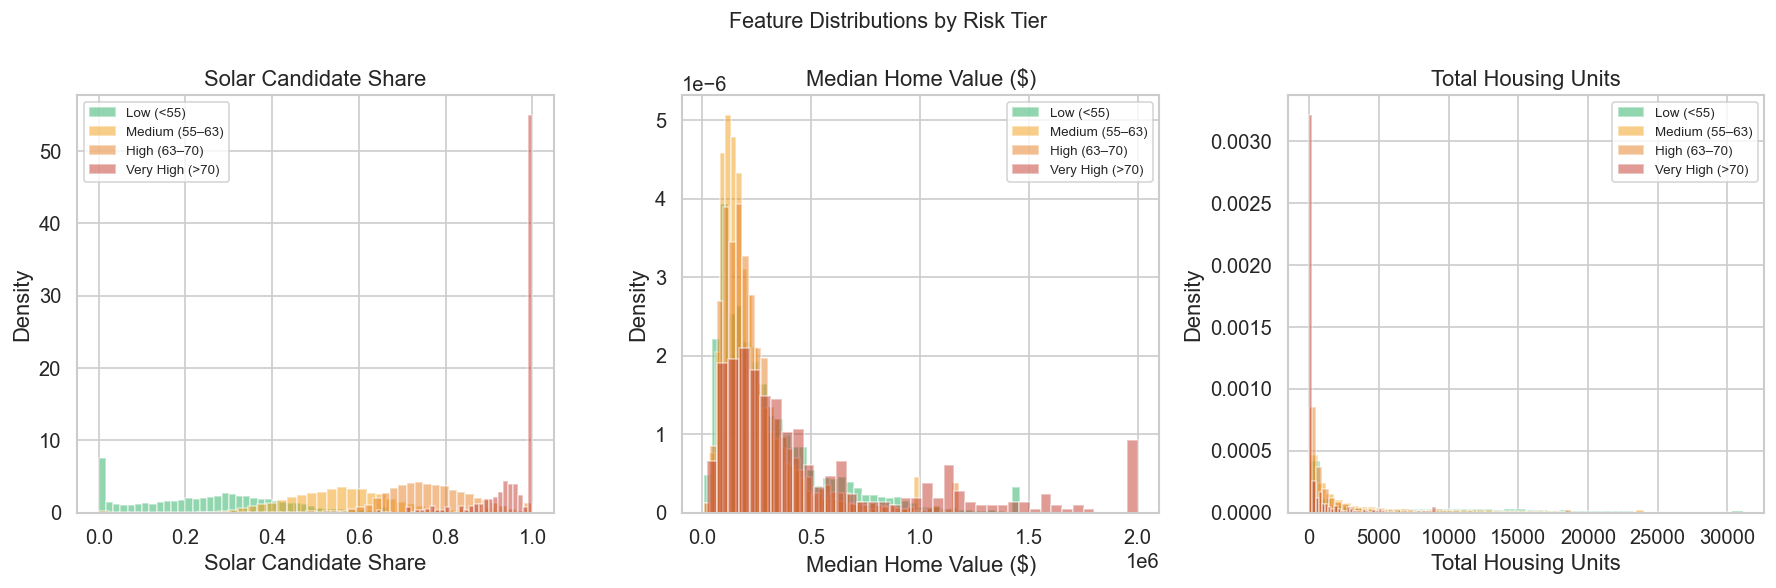

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

feature_to_plot = [
    ('solar_candidate_share', 'Solar Candidate Share'),
    ('median_home_value',     'Median Home Value ($)'),
    ('total_housing_units',   'Total Housing Units'),
]

tier_colors = ['#27ae60', '#f39c12', '#e67e22', '#c0392b']

for ax, (col, label) in zip(axes, feature_to_plot):
    for tier, color in zip(df['risk_tier'].cat.categories, tier_colors):
        subset = df.loc[df['risk_tier'] == tier, col].dropna()
        # Clip at 99th pct for visibility
        ax.hist(subset.clip(upper=subset.quantile(0.99)), bins=40, alpha=0.5, label=tier, color=color, density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Risk Tier', fontsize=13)
plt.tight_layout()
plt.show()

---
## 13. Housing Density vs. Solar Suitability

Urban density is the enemy of rooftop solar — apartments can't host panels.

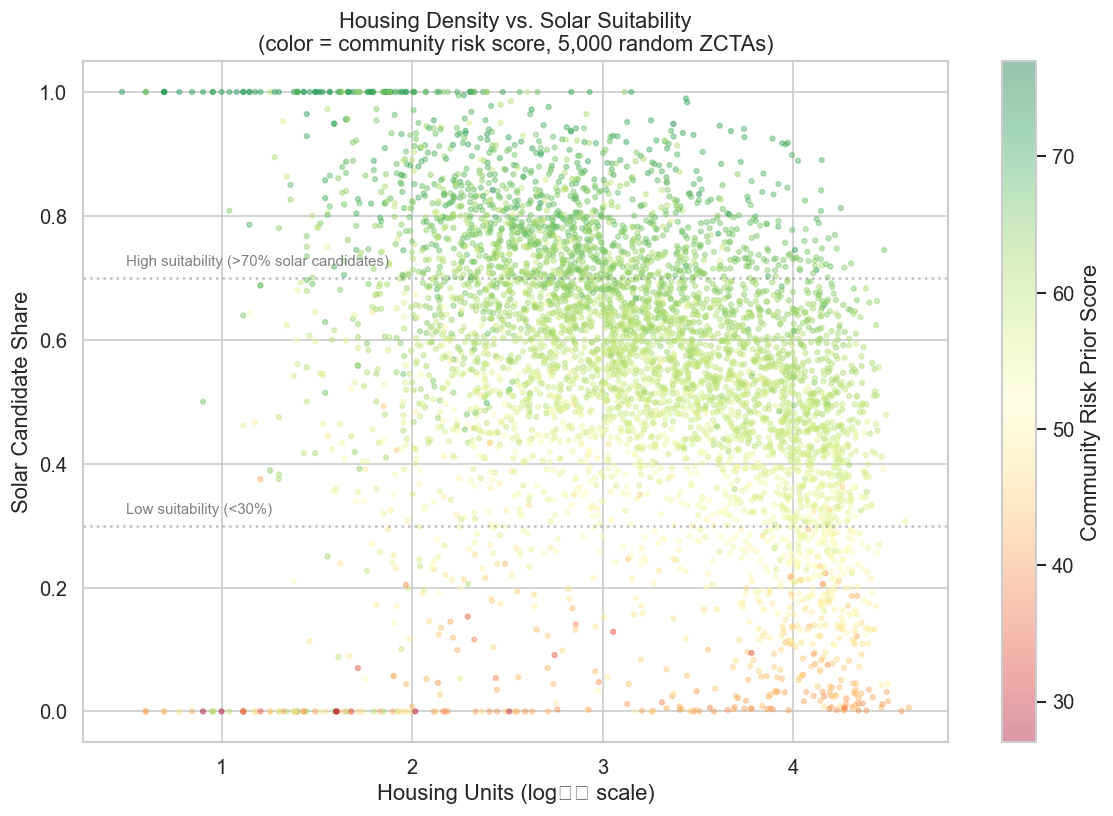

In [52]:
fig, ax = plt.subplots(figsize=(10, 7))

# Sample for scatter visibility
sample = df.sample(5000, random_state=42)

scatter = ax.scatter(
    np.log10(sample['total_housing_units'].clip(lower=1)),
    sample['solar_candidate_share'],
    c=sample['community_risk_prior_score'],
    cmap='RdYlGn', alpha=0.4, s=8, vmin=27, vmax=77
)

plt.colorbar(scatter, ax=ax, label='Community Risk Prior Score')
ax.set_xlabel('Housing Units (log₁₀ scale)')
ax.set_ylabel('Solar Candidate Share')
ax.set_title('Housing Density vs. Solar Suitability\n(color = community risk score, 5,000 random ZCTAs)')

# Annotate density zones
ax.axhline(0.7, color='grey', linestyle=':', alpha=0.5)
ax.text(0.05, 0.72, 'High suitability (>70% solar candidates)', transform=ax.get_yaxis_transform(), fontsize=9, color='grey')
ax.axhline(0.3, color='grey', linestyle=':', alpha=0.5)
ax.text(0.05, 0.32, 'Low suitability (<30%)', transform=ax.get_yaxis_transform(), fontsize=9, color='grey')

plt.tight_layout()
plt.show()

---
## 14. Income & Home Value — The Affordability Lens

Solar adoption correlates with income and home value — higher-income homeowners have more capital and longer time horizons.

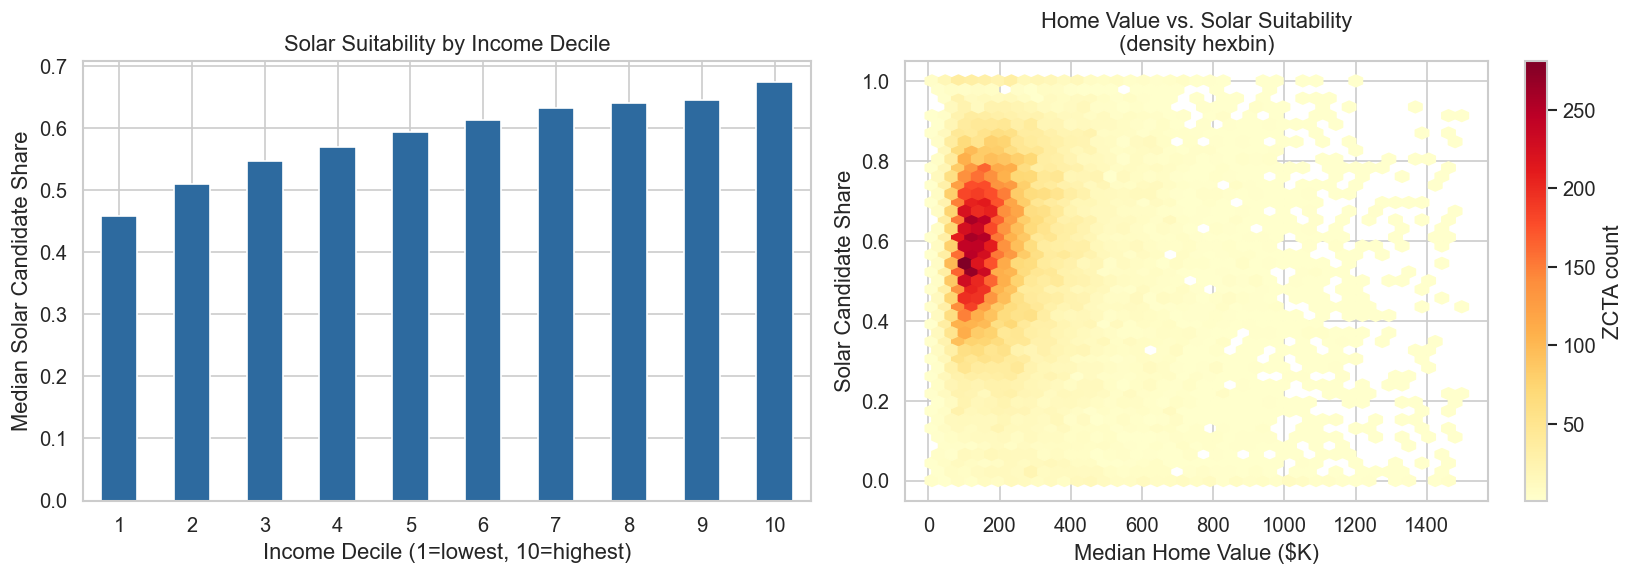

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income deciles vs. solar candidate share
ax = axes[0]
df_income = df.dropna(subset=['median_household_income']).copy()
df_income['income_decile'] = pd.qcut(df_income['median_household_income'], 10, labels=False) + 1
decile_solar = df_income.groupby('income_decile')['solar_candidate_share'].median()
decile_solar.plot(kind='bar', ax=ax, color='#2d6a9f', edgecolor='white')
ax.set_xlabel('Income Decile (1=lowest, 10=highest)')
ax.set_ylabel('Median Solar Candidate Share')
ax.set_title('Solar Suitability by Income Decile')
ax.tick_params(axis='x', rotation=0)

# Home value vs. solar candidate share hexbin
ax = axes[1]
plot_df = df.dropna(subset=['median_home_value'])
plot_df = plot_df[plot_df['median_home_value'] < 1_500_000]  # Remove extreme outliers for readability
hb = ax.hexbin(
    plot_df['median_home_value'] / 1000,
    plot_df['solar_candidate_share'],
    gridsize=40, cmap='YlOrRd', mincnt=1
)
plt.colorbar(hb, ax=ax, label='ZCTA count')
ax.set_xlabel('Median Home Value ($K)')
ax.set_ylabel('Solar Candidate Share')
ax.set_title('Home Value vs. Solar Suitability\n(density hexbin)')

plt.tight_layout()
plt.show()

---
## 15. Data Quality Summary

What needs attention before training a model.

In [54]:
issues = [
    ('Constant cyber pressure', 
     'solar_cyber_pressure_score is identical for every ZCTA (61.48). Cyber variation is at the vendor level, not yet geographic.',
     'Medium — scores still vary meaningfully via solar_readiness_score'),
    
    ('Missing home value / income', 
     f"{df['median_home_value'].isnull().sum():,} ZCTAs ({df['median_home_value'].isnull().mean()*100:.1f}%) missing median_home_value. Concentrated in small rural ZCTAs.",
     'Low — Census suppresses small-sample estimates; impute with state median or drop'),
    
    ('Missing year built', 
     f"{df['median_year_built'].isnull().sum():,} ZCTAs missing median_year_built.",
     'Low — impute with national median (~1978)'),
    
    ('No garage data from Census', 
     'garage_share = 0 for all ZCTAs (Census ACS does not track garage counts). Present in Melissa property data but only for 1 ZIP.',
     'Low — the model weight for this feature is only 10%'),
    
    ('No geographic labels', 
     'State FIPS is not in the final dataset — need to join via a ZIP→state crosswalk for state-level analysis or map coloring.',
     'Medium — needed for dashboard/choropleth'),
    
    ('No solar adoption ground truth', 
     'No actual solar panel count per ZCTA. model is a prior, not a trained classifier. Validation would require SEIA or permit data.',
     'High for model validation — not blocking for v1 demo'),
    
    ('Income Census cap', 
     'median_household_income caps at $250,001 — all high-income ZCTAs are indistinguishable at the top.',
     'Low — use high_value_share as proxy for luxury communities'),
]

issues_df = pd.DataFrame(issues, columns=['Issue', 'Detail', 'Severity'])
issues_df.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
)

,Issue,Detail,Severity
0,Constant cyber pressure,"solar_cyber_pressure_score is identical for every ZCTA (61.48). Cyber variation is at the vendor level, not yet geographic.",Medium — scores still vary meaningfully via solar_readiness_score
1,Missing home value / income,"2,579 ZCTAs (7.8%) missing median_home_value. Concentrated in small rural ZCTAs.",Low — Census suppresses small-sample estimates; impute with state median or drop
2,Missing year built,690 ZCTAs missing median_year_built.,Low — impute with national median (~1978)
3,No garage data from Census,garage_share = 0 for all ZCTAs (Census ACS does not track garage counts). Present in Melissa property data but only for 1 ZIP.,Low — the model weight for this feature is only 10%
4,No geographic labels,State FIPS is not in the final dataset — need to join via a ZIP→state crosswalk for state-level analysis or map coloring.,Medium — needed for dashboard/choropleth
5,No solar adoption ground truth,"No actual solar panel count per ZCTA. model is a prior, not a trained classifier. Validation would require SEIA or permit data.",High for model validation — not blocking for v1 demo
6,Income Census cap,"median_household_income caps at $250,001 — all high-income ZCTAs are indistinguishable at the top.",Low — use high_value_share as proxy for luxury communities


---
## 16. Summary — What You're Working With

| Dimension | Value |
|-----------|-------|
| Rows (ZCTAs) | 32,958 |
| Feature columns | 32 (excluding ID and aliases) |
| Cyber CVEs | 83 unique CVEs, 13 vendors |
| Target score range | 27.7 – 77.2 |
| Score mean / std | 59.2 / 6.5 |
| Top risk ZCTAs | Affluent suburban SF communities (CA Bay Area, NY suburbs, CO foothills) |
| Low risk ZCTAs | Dense urban cores — Manhattan, downtown Chicago, Miami Beach |
| Missing data | ~8% for home value/income; 2% for year built — mostly rural ZCTAs |
| Key limitation | Cyber pressure is a global constant — no geographic cyber variation yet |

### The score is doing the right thing

The communities at the top of the ranking (high-income suburban owner-occupied single-family neighborhoods) are **exactly** where residential solar adoption is highest per EIA and SEIA data. The model hasn't been trained on adoption data — it's inferring it from housing structure — and the result is directionally correct.

### What a v2 would add

1. **Geography-specific cyber pressure** — vendor market share by region (e.g., Enphase dominates CA, SMA dominates Northeast)
2. **SEIA solar permit data** as training labels for supervised learning
3. **Irradiance features** from NREL's National Solar Radiation Database
4. **Utility territory overlay** to map risk scores to specific grid operators
5. **Shodan enrichment** — actual device exposure counts per region